In [29]:
# 1. Mount Google Drive and imports

from google.colab import drive
drive.mount('/content/drive')

import os
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, jaccard_score

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [33]:
# 2. Configuration + training size toggle

class CFG:
    DATA_ROOT = "/content/drive/MyDrive/ecssd"

    IMG_DIR = f"{DATA_ROOT}/images (1)"
    MASK_DIR = f"{DATA_ROOT}/ground_truth_mask"

    IMG_SIZE = 128
    BATCH_SIZE = 8
    EPOCHS = 15
    SEED = 42

    MODEL_DIR = "/content/models"
    LOG_DIR = "/content/logs"


FAST_MODE = False

if FAST_MODE:
    MAX_TOTAL_IMAGES = 300
else:
    MAX_TOTAL_IMAGES = None


print("FAST_MODE:", FAST_MODE)
print("MAX_TOTAL_IMAGES:", MAX_TOTAL_IMAGES)

os.makedirs(CFG.MODEL_DIR, exist_ok=True)
os.makedirs(CFG.LOG_DIR, exist_ok=True)

random.seed(CFG.SEED)
np.random.seed(CFG.SEED)
tf.random.set_seed(CFG.SEED)

FAST_MODE: False
MAX_TOTAL_IMAGES: None


In [34]:
# 3. Pair images with masks

def collect_pairs(image_dir, mask_dir):
    image_dir = Path(image_dir)
    mask_dir = Path(mask_dir)

    print("Image folder exists:", image_dir.exists())
    print("Mask folder exists:", mask_dir.exists())

    image_paths = sorted(
        list(image_dir.glob("*.jpg")) +
        list(image_dir.glob("*.jpeg")) +
        list(image_dir.glob("*.png"))
    )

    print("Images found:", len(image_paths))

    pairs = []

    for img_path in image_paths:
        possible_masks = [
            mask_dir / f"{img_path.stem}.png",
            mask_dir / f"{img_path.stem}.jpg",
            mask_dir / f"{img_path.stem}.jpeg",
        ]

        for mask_path in possible_masks:
            if mask_path.exists():
                pairs.append((str(img_path), str(mask_path)))
                break

    return pairs


all_pairs = collect_pairs(CFG.IMG_DIR, CFG.MASK_DIR)

random.seed(CFG.SEED)
random.shuffle(all_pairs)

if MAX_TOTAL_IMAGES is not None:
    all_pairs = all_pairs[:MAX_TOTAL_IMAGES]

print("Total image/mask pairs used:", len(all_pairs))
print("Example pair:", all_pairs[0] if all_pairs else "No data found")

Image folder exists: True
Mask folder exists: True
Images found: 1000
Total image/mask pairs used: 1000
Example pair: ('/content/drive/MyDrive/ecssd/images (1)/0777.jpg', '/content/drive/MyDrive/ecssd/ground_truth_mask/0777.png')


In [36]:
# 4. Proper 70% train / 15% validation / 15% test split

train_pairs, temp_pairs = train_test_split(
    all_pairs,
    test_size=0.30,
    random_state=CFG.SEED,
    shuffle=True
)

val_pairs, test_pairs = train_test_split(
    temp_pairs,
    test_size=0.50,
    random_state=CFG.SEED,
    shuffle=True
)

total = len(all_pairs)

print("Train:", len(train_pairs), f"({len(train_pairs) / total:.1%})")
print("Validation:", len(val_pairs), f"({len(val_pairs) / total:.1%})")
print("Test:", len(test_pairs), f"({len(test_pairs) / total:.1%})")

Train: 700 (70.0%)
Validation: 150 (15.0%)
Test: 150 (15.0%)


In [37]:
# 5. Preprocessing: resize + normalize images and masks to [0, 1]

def load_image_and_mask(img_path, mask_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (CFG.IMG_SIZE, CFG.IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, (CFG.IMG_SIZE, CFG.IMG_SIZE), method="nearest")
    mask = tf.cast(mask, tf.float32) / 255.0

    # Make sure mask is binary-ish
    mask = tf.where(mask > 0.5, 1.0, 0.0)

    return img, mask


def augment_image_and_mask(img, mask):
    # Horizontal flip
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)

    # Brightness variation only on image
    img = tf.image.random_brightness(img, max_delta=0.15)
    img = tf.clip_by_value(img, 0.0, 1.0)

    # Random crop-like zoom: resize larger then random crop back
    if tf.random.uniform(()) > 0.5:
        bigger = CFG.IMG_SIZE + 32
        img = tf.image.resize(img, (bigger, bigger))
        mask = tf.image.resize(mask, (bigger, bigger), method="nearest")

        combined = tf.concat([img, mask], axis=-1)
        combined = tf.image.random_crop(combined, size=(CFG.IMG_SIZE, CFG.IMG_SIZE, 4))

        img = combined[:, :, :3]
        mask = combined[:, :, 3:]
        mask = tf.where(mask > 0.5, 1.0, 0.0)

    return img, mask


def make_dataset(pairs, training=False):
    img_paths = [p[0] for p in pairs]
    mask_paths = [p[1] for p in pairs]

    ds = tf.data.Dataset.from_tensor_slices((img_paths, mask_paths))
    ds = ds.map(load_image_and_mask, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.shuffle(buffer_size=len(pairs), seed=CFG.SEED)
        ds = ds.map(augment_image_and_mask, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(CFG.BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_pairs, training=True)
val_ds = make_dataset(val_pairs, training=False)
test_ds = make_dataset(test_pairs, training=False)

print("Datasets ready.")


Datasets ready.


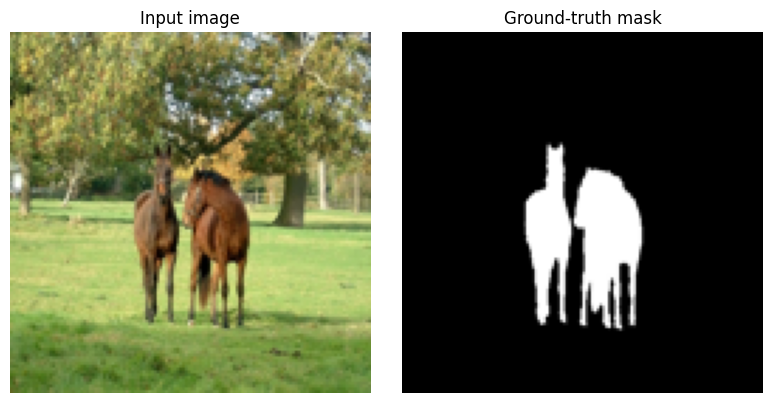

In [38]:
# 6. Fast visualization from original pairs

def show_one_raw_sample(pairs):
    img_path, mask_path = pairs[0]

    img = Image.open(img_path).convert("RGB")
    mask = Image.open(mask_path).convert("L")

    img = img.resize((CFG.IMG_SIZE, CFG.IMG_SIZE))
    mask = mask.resize((CFG.IMG_SIZE, CFG.IMG_SIZE))

    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Input image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap="gray")
    plt.title("Ground-truth mask")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

show_one_raw_sample(train_pairs)


In [39]:
# 7. Metrics and loss

SMOOTH = 1e-6

def dice_coef(y_true, y_pred):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * intersection + SMOOTH) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + SMOOTH
    )

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

def iou_metric_tf(y_true, y_pred):
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    y_true = tf.cast(y_true > 0.5, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection

    return (intersection + SMOOTH) / (union + SMOOTH)


In [40]:
# 8. U-Net model from scratch

def conv_block(x, filters, dropout_rate=0.0):
    x = layers.Conv2D(filters, 3, padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters, 3, padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)

    return x

def encoder_block(x, filters, dropout_rate=0.0):
    skip = conv_block(x, filters, dropout_rate)
    pooled = layers.MaxPooling2D((2, 2))(skip)
    return skip, pooled

def decoder_block(x, skip, filters, dropout_rate=0.0):
    x = layers.Conv2DTranspose(filters, 2, strides=2, padding="same")(x)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters, dropout_rate)
    return x

def build_unet(input_shape=(256, 256, 3), base_filters=32, dropout_rate=0.0):
    inputs = layers.Input(input_shape)

    s1, p1 = encoder_block(inputs, base_filters, dropout_rate)
    s2, p2 = encoder_block(p1, base_filters * 2, dropout_rate)
    s3, p3 = encoder_block(p2, base_filters * 4, dropout_rate)
    s4, p4 = encoder_block(p3, base_filters * 8, dropout_rate)

    bridge = conv_block(p4, base_filters * 16, dropout_rate)

    d1 = decoder_block(bridge, s4, base_filters * 8, dropout_rate)
    d2 = decoder_block(d1, s3, base_filters * 4, dropout_rate)
    d3 = decoder_block(d2, s2, base_filters * 2, dropout_rate)
    d4 = decoder_block(d3, s1, base_filters, dropout_rate)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(d4)

    return models.Model(inputs, outputs, name=f"UNet_base{base_filters}_dropout{dropout_rate}")


In [41]:
# 9. Training helper

def compile_model(model, learning_rate=1e-4):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate),
        loss=bce_dice_loss,
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            dice_coef,
            iou_metric_tf,
        ],
    )
    return model


def get_callbacks(model_name):
    return [
        ModelCheckpoint(
            filepath=f"{CFG.MODEL_DIR}/{model_name}.keras",
            monitor="val_iou_metric_tf",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
        EarlyStopping(
            monitor="val_iou_metric_tf",
            mode="max",
            patience=4,
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=2,
            min_lr=1e-6,
            verbose=1,
        ),
        CSVLogger(f"{CFG.LOG_DIR}/{model_name}_training_log.csv"),
    ]


def train_model(model, model_name):
    model = compile_model(model)
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=CFG.EPOCHS,
        callbacks=get_callbacks(model_name),
    )
    return model, history


In [42]:
# 10. Experiment 1: Baseline model

baseline_model = build_unet(
    input_shape=(CFG.IMG_SIZE, CFG.IMG_SIZE, 3),
    base_filters=8,
    dropout_rate=0.0
)

baseline_model.summary()

baseline_model, baseline_history = train_model(
    baseline_model,
    model_name="baseline_unet"
)


Model: "UNet_base8_dropout0.0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        224 │ input_layer[0][0] │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │         32 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │        584 │ activation[0][0]  │
│                     │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │         32 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64, 8) │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      1,168 │ max_pooling2d[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │         64 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      2,320 │ activation_2[0][… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │         64 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │      4,640 │ max_pooling2d_1[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_4[0][0]  

 Total params: 488,761 (1.86 MB)

 Trainable params: 487,289 (1.86 MB)

 Non-trainable params: 1,472 (5.75 KB)

Epoch 1/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.4183 - dice_coef: 0.3843 - iou_metric_tf: 0.2601 - loss: 1.4253 - precision: 0.2874 - recall: 0.7377
Epoch 1: val_iou_metric_tf improved from None to 0.25051, saving model to /content/models/baseline_unet.keras

Epoch 1: finished saving model to /content/models/baseline_unet.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 199s 469ms/step - accuracy: 0.4375 - dice_coef: 0.3876 - iou_metric_tf: 0.2658 - loss: 1.4052 - precision: 0.2960 - recall: 0.7284 - val_accuracy: 0.5108 - val_dice_coef: 0.3446 - val_iou_metric_tf: 0.2505 - val_loss: 1.3461 - val_precision: 0.2909 - val_recall: 0.6407 - learning_rate: 1.0000e-04
Epoch 2/15
86/88 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5254 - dice_coef: 0.3908 - iou_metric_tf: 0.2758 - loss: 1.3424 - precision: 0.3217 - recall: 0.6599
Epoch 2: val_iou_metric_tf did not improve from 0.25051
88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.5666 - dice_coef: 0.4006 - iou_metric_tf: 0.2947 - 

In [58]:
# 11. Experiment 2: Improved model
# Improvement 1: more filters
# Improvement 2: dropout regularization
# Augmentation is already applied in the training dataset.

improved_model = build_unet(
    input_shape=(CFG.IMG_SIZE, CFG.IMG_SIZE, 3),
    base_filters=32,
    dropout_rate=0.05
)

improved_model.summary()

improved_model, improved_history = train_model(
    improved_model,
    model_name="improved_unet"
)


Model: "UNet_base32_dropout0.05"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 128, 128,  │        896 │ input_layer_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_95[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_90       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, 128, 128,  │      9,248 │ activation_90[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_96[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_91       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_27          │ (None, 128, 128,  │          0 │ activation_91[0]… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_20    │ (None, 64, 64,    │          0 │ dropout_27[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_97 (Conv2D)  │ (None, 64, 64,    │     18,496 │ max_pooling2d_20… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_97[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_92       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_98 (Conv2D)  │ (None, 64, 64,    │     36,928 │ activation_92[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_98[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_93       │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_28          │ (None, 64, 64,    │          0 │ activation_93[0]… │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_21    │ (None, 32, 32,    │          0 │ dropout_28[0][0]

 Total params: 7,771,873 (29.65 MB)

 Trainable params: 7,765,985 (29.62 MB)

 Non-trainable params: 5,888 (23.00 KB)

Epoch 1/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - accuracy: 0.4227 - dice_coef: 0.4165 - iou_metric_tf: 0.2932 - loss: 1.4905 - precision: 0.3097 - recall: 0.8412
Epoch 1: val_iou_metric_tf improved from None to 0.21056, saving model to /content/models/improved_unet.keras

Epoch 1: finished saving model to /content/models/improved_unet.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 75s 376ms/step - accuracy: 0.5162 - dice_coef: 0.4217 - iou_metric_tf: 0.3092 - loss: 1.3831 - precision: 0.3391 - recall: 0.7550 - val_accuracy: 0.7070 - val_dice_coef: 0.3415 - val_iou_metric_tf: 0.2106 - val_loss: 1.2981 - val_precision: 0.4013 - val_recall: 0.3054 - learning_rate: 1.0000e-04
Epoch 2/15
87/88 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7132 - dice_coef: 0.4545 - iou_metric_tf: 0.3791 - loss: 1.1811 - precision: 0.4870 - recall: 0.6270
Epoch 2: val_iou_metric_tf improved from 0.21056 to 0.43906, saving model to /content/models/improved_unet.keras

Epoch 2: finished saving model to /content/model

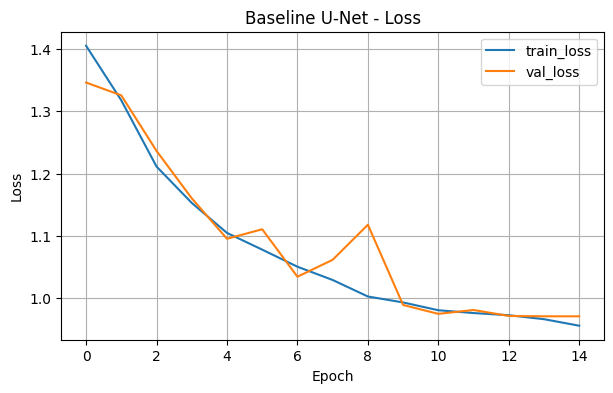

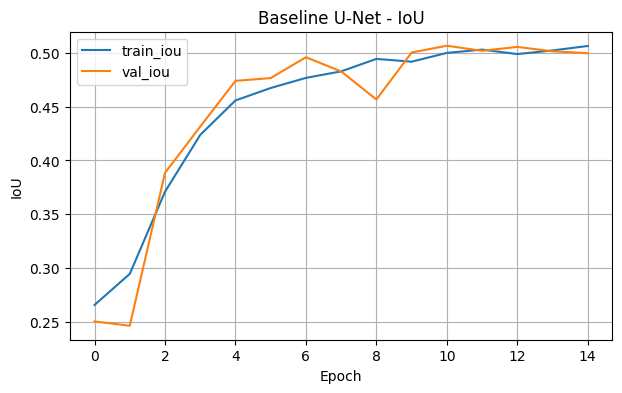

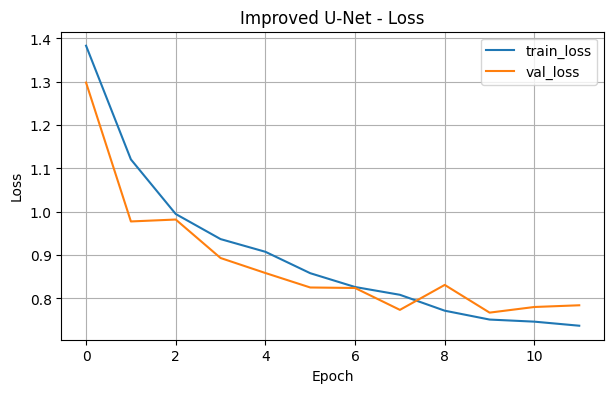

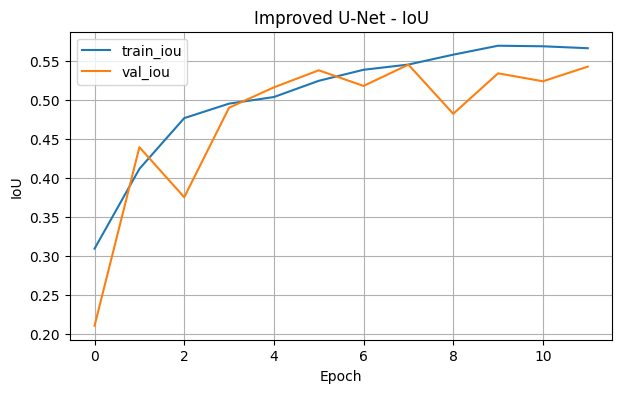

In [59]:
# 12. Plot training curves

def plot_history(history, title):
    hist = history.history

    plt.figure(figsize=(7, 4))
    plt.plot(hist["loss"], label="train_loss")
    plt.plot(hist["val_loss"], label="val_loss")
    plt.title(title + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(hist["iou_metric_tf"], label="train_iou")
    plt.plot(hist["val_iou_metric_tf"], label="val_iou")
    plt.title(title + " - IoU")
    plt.xlabel("Epoch")
    plt.ylabel("IoU")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history(baseline_history, "Baseline U-Net")
plot_history(improved_history, "Improved U-Net")


In [60]:
# 13. Final evaluation on TEST set
# This calculates IoU, Precision, Recall, F1, Dice, and average inference time.

def evaluate_segmentation_model(model, ds, threshold=0.5):
    all_true = []
    all_pred = []

    inference_times = []

    for imgs, masks in ds:
        start = time.time()
        preds = model.predict(imgs, verbose=0)
        end = time.time()

        batch_time = (end - start) / imgs.shape[0]
        inference_times.extend([batch_time] * imgs.shape[0])

        preds_binary = (preds > threshold).astype(np.uint8)
        masks_binary = (masks.numpy() > threshold).astype(np.uint8)

        all_true.append(masks_binary.reshape(-1))
        all_pred.append(preds_binary.reshape(-1))

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    iou = jaccard_score(y_true, y_pred, zero_division=0)

    dice = (2 * precision * recall) / (precision + recall + 1e-6)
    avg_inference_time = float(np.mean(inference_times))

    return {
        "IoU": iou,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Dice": dice,
        "Avg inference time / image (sec)": avg_inference_time,
    }

baseline_results = evaluate_segmentation_model(baseline_model, test_ds)
improved_results = evaluate_segmentation_model(improved_model, test_ds)

results_df = pd.DataFrame([
    {"Model": "Baseline U-Net", **baseline_results},
    {"Model": "Improved U-Net", **improved_results},
])

results_df


,Model,IoU,Precision,Recall,F1,Dice,Avg inference time / image (sec)
0,Baseline U-Net,0.480495,0.553407,0.784806,0.649100,0.649100,0.018540
1,Improved U-Net,0.529393,0.612171,0.796543,0.692292,0.692291,0.037871


In [50]:
# 14. Save experiment comparison table

results_path = "/content/sod_experiment_results.csv"
results_df.to_csv(results_path, index=False)
print("Saved:", results_path)
results_df


Saved: /content/sod_experiment_results.csv


,Model,IoU,Precision,Recall,F1,Dice,Avg inference time / image (sec)
0,Baseline U-Net,0.480495,0.553407,0.784806,0.649100,0.649100,0.016880
1,Improved U-Net,0.383924,0.607744,0.510399,0.554834,0.554834,0.037168


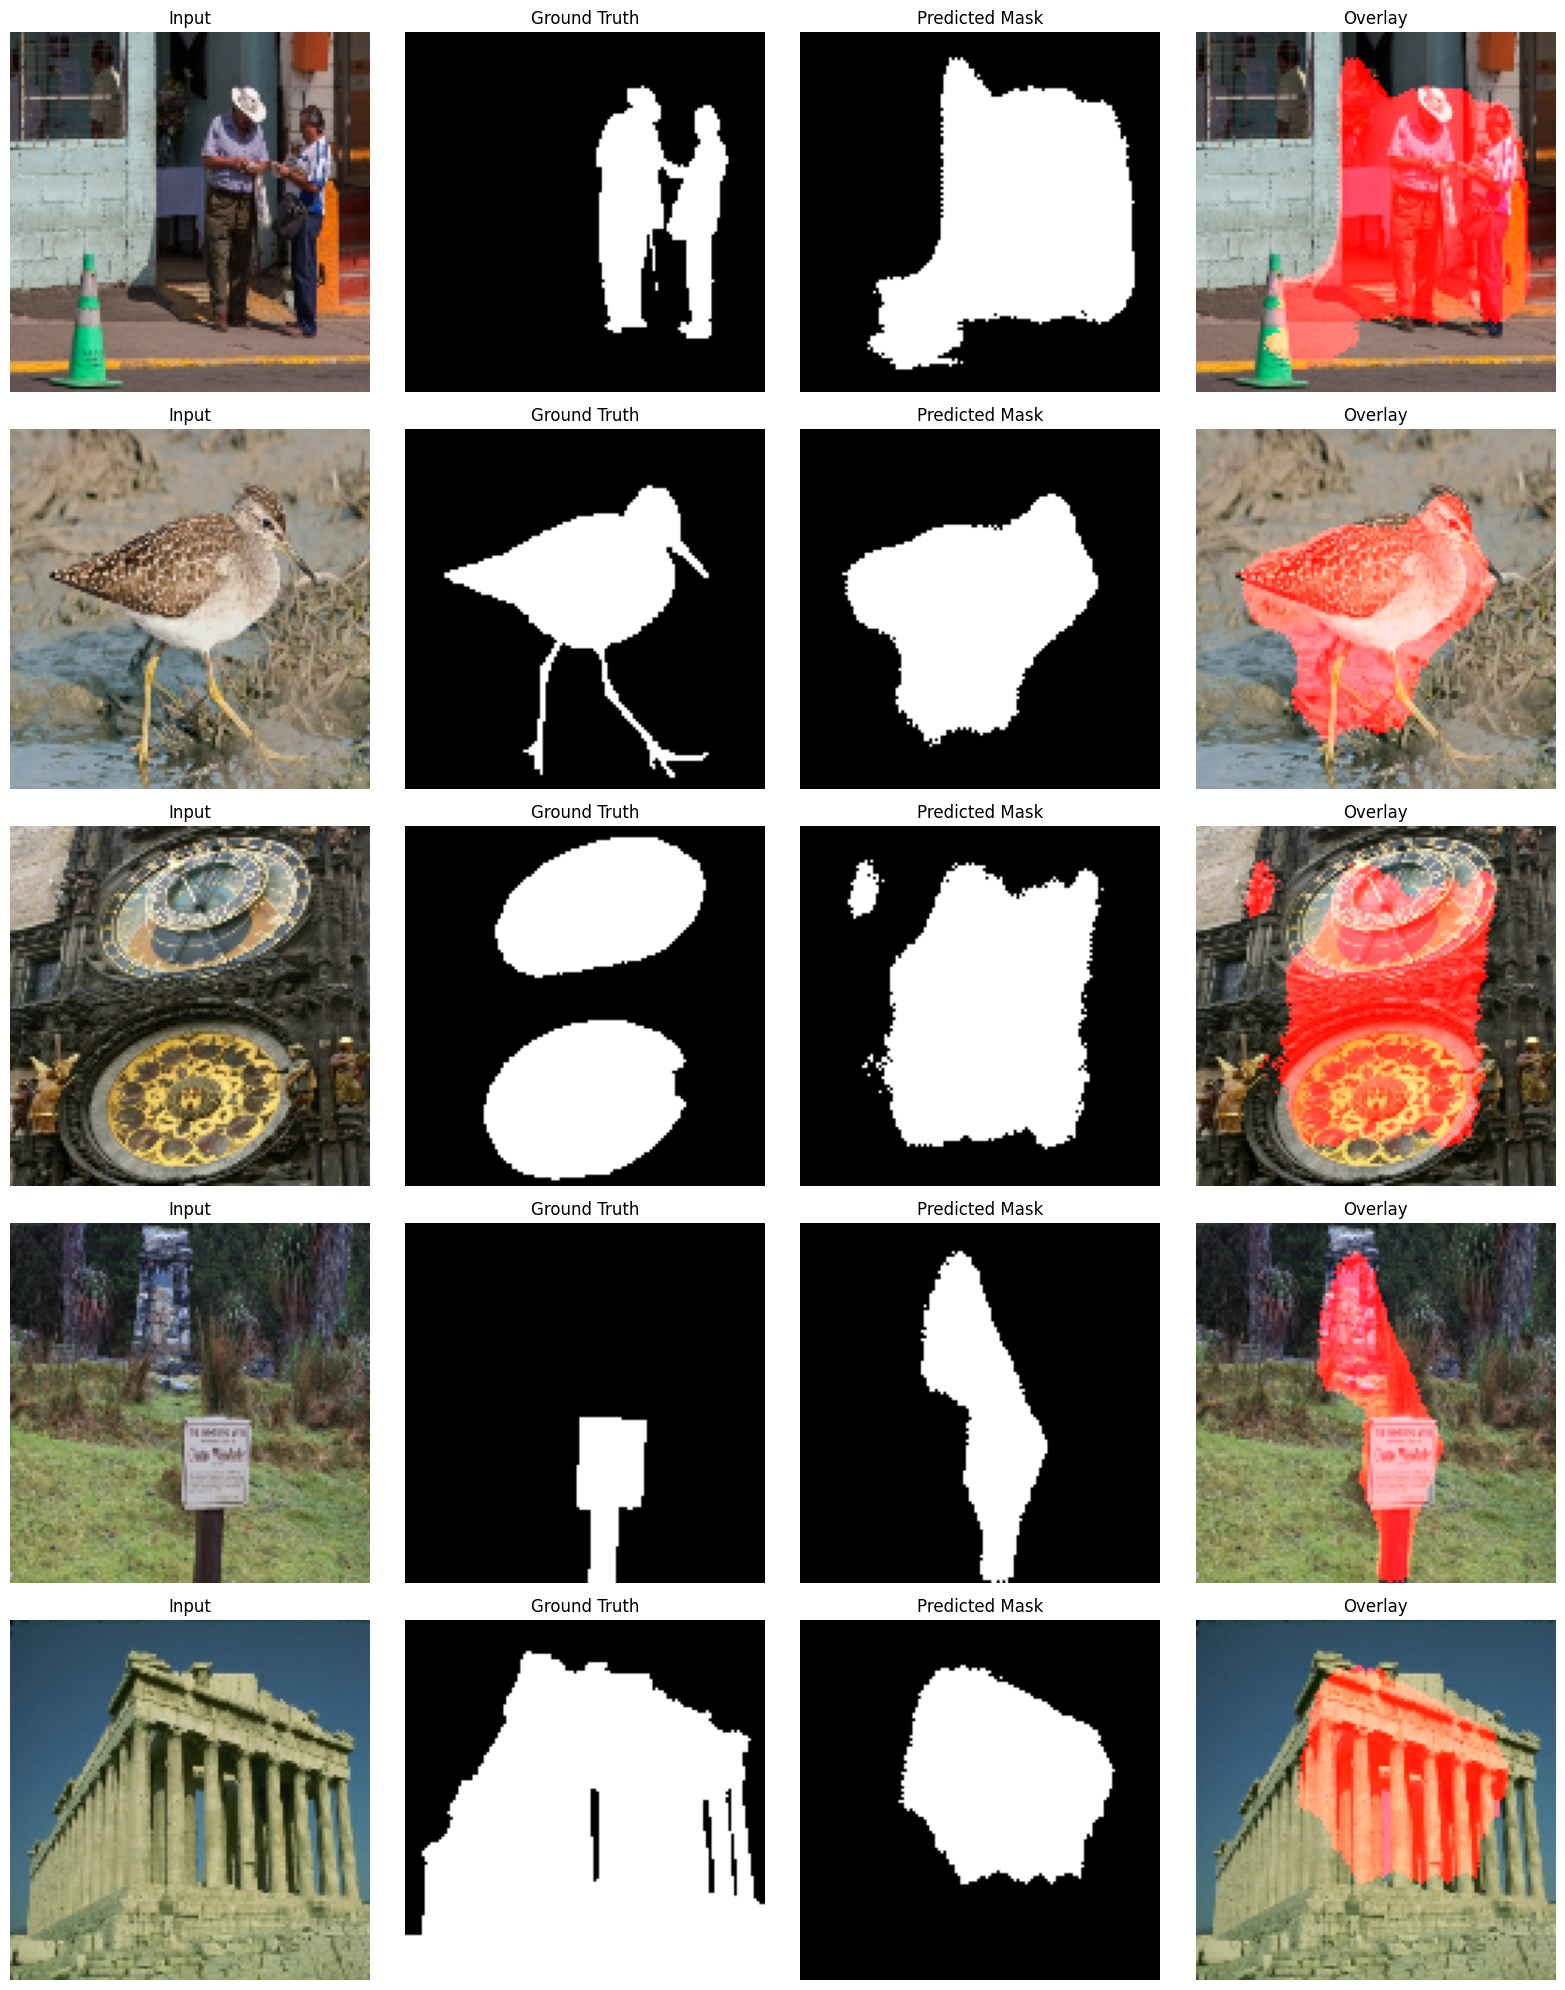

In [61]:
# 15. Visualization: original image, ground truth, prediction, and overlay

def show_predictions_with_overlay(model, ds, n=5, threshold=0.5):
    imgs, masks = next(iter(ds))
    preds = model.predict(imgs, verbose=0)

    n = min(n, imgs.shape[0])
    plt.figure(figsize=(16, 4 * n))

    for i in range(n):
        img = imgs[i].numpy()
        gt = masks[i].numpy().squeeze()
        pred = preds[i].squeeze()
        pred_bin = (pred > threshold).astype(np.float32)

        overlay = img.copy()
        # Highlight predicted foreground by increasing red channel
        overlay[:, :, 0] = np.maximum(overlay[:, :, 0], pred_bin)

        plt.subplot(n, 4, 4*i + 1)
        plt.imshow(img)
        plt.title("Input")
        plt.axis("off")

        plt.subplot(n, 4, 4*i + 2)
        plt.imshow(gt, cmap="gray")
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(n, 4, 4*i + 3)
        plt.imshow(pred_bin, cmap="gray")
        plt.title("Predicted Mask")
        plt.axis("off")

        plt.subplot(n, 4, 4*i + 4)
        plt.imshow(overlay)
        plt.title("Overlay")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_predictions_with_overlay(improved_model, test_ds, n=5)


In [62]:
# 16. Single image demo function

def predict_single_image(model, image_path, threshold=0.5):
    original = Image.open(image_path).convert("RGB")
    resized = original.resize((CFG.IMG_SIZE, CFG.IMG_SIZE))

    img = np.array(resized).astype(np.float32) / 255.0
    img_batch = np.expand_dims(img, axis=0)

    start = time.time()
    pred = model.predict(img_batch, verbose=0)[0, :, :, 0]
    end = time.time()

    pred_bin = (pred > threshold).astype(np.float32)

    overlay = img.copy()
    overlay[:, :, 0] = np.maximum(overlay[:, :, 0], pred_bin)

    print(f"Inference time: {end - start:.4f} seconds")

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(pred_bin, cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# Example:
# predict_single_image(improved_model, test_pairs[0][0])


Click 'Choose Files' and upload one image for the demo.


Saving ILSVRC2012_test_00000262.jpg to ILSVRC2012_test_00000262.jpg
Uploaded image: ILSVRC2012_test_00000262.jpg
Inference time: 0.0951 seconds


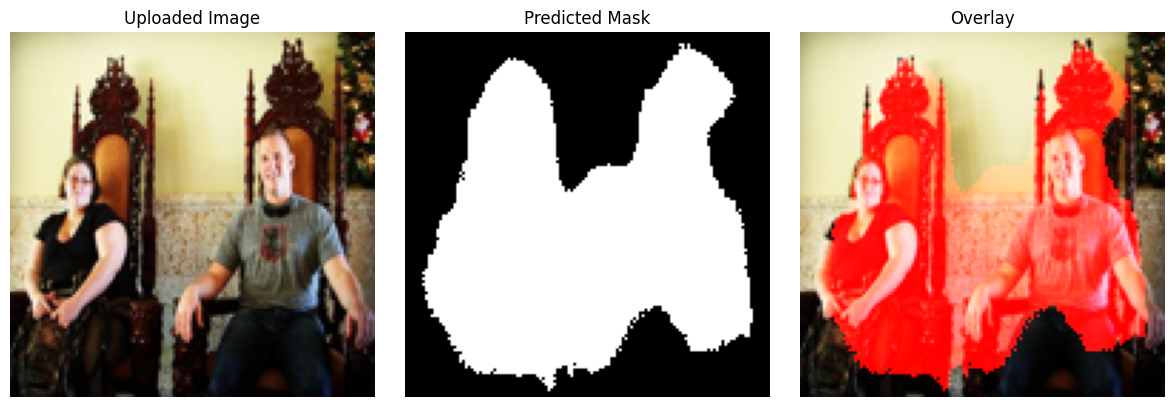

In [76]:
# 17. Demo: upload one image and predict mask

from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import time
import os

print("Click 'Choose Files' and upload one image for the demo.")

uploaded = files.upload()

if len(uploaded) == 0:
    print("No image uploaded.")
else:
    uploaded_filename = list(uploaded.keys())[0]
    print("Uploaded image:", uploaded_filename)

    # Use the improved model if it exists in memory.
    # If not, load the saved improved model from /content/models.
    if "improved_model" not in globals():
        print("Loading saved improved model...")
        improved_model = tf.keras.models.load_model(
            "/content/models/improved_unet.keras",
            custom_objects={
                "bce_dice_loss": bce_dice_loss,
                "dice_coef": dice_coef,
                "iou_metric_tf": iou_metric_tf
            }
        )

    original = Image.open(uploaded_filename).convert("RGB")
    resized = original.resize((CFG.IMG_SIZE, CFG.IMG_SIZE))

    img = np.array(resized).astype(np.float32) / 255.0
    img_batch = np.expand_dims(img, axis=0)

    start = time.time()
    pred = improved_model.predict(img_batch, verbose=0)[0, :, :, 0]
    end = time.time()

    pred_bin = (pred > 0.5).astype(np.float32)

    overlay = img.copy()
    overlay[:, :, 0] = np.maximum(overlay[:, :, 0], pred_bin)

    print(f"Inference time: {end - start:.4f} seconds")

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Uploaded Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(pred_bin, cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title("Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
baseline_model.save("/content/drive/MyDrive/ecssd/baseline_unet.keras")
improved_model.save("/content/drive/MyDrive/ecssd/improved_unet.keras")

